In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

print("Token loaded successfully!")

Token loaded successfully!


In [ ]:
import kagglehub

# Download latest version of Loveda dataset
path = kagglehub.dataset_download("mohammedjaveed/loveda-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.92G/8.92G [01:48<00:00, 88.3MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mohammedjaveed/loveda-dataset/versions/1


Dataset downloaded to: /root/.cache/kagglehub/datasets/mohammedjaveed/loveda-dataset/versions/1
Found 2522 images for Train split.
Found 1669 images for Val split.
Visualizing a training batch...


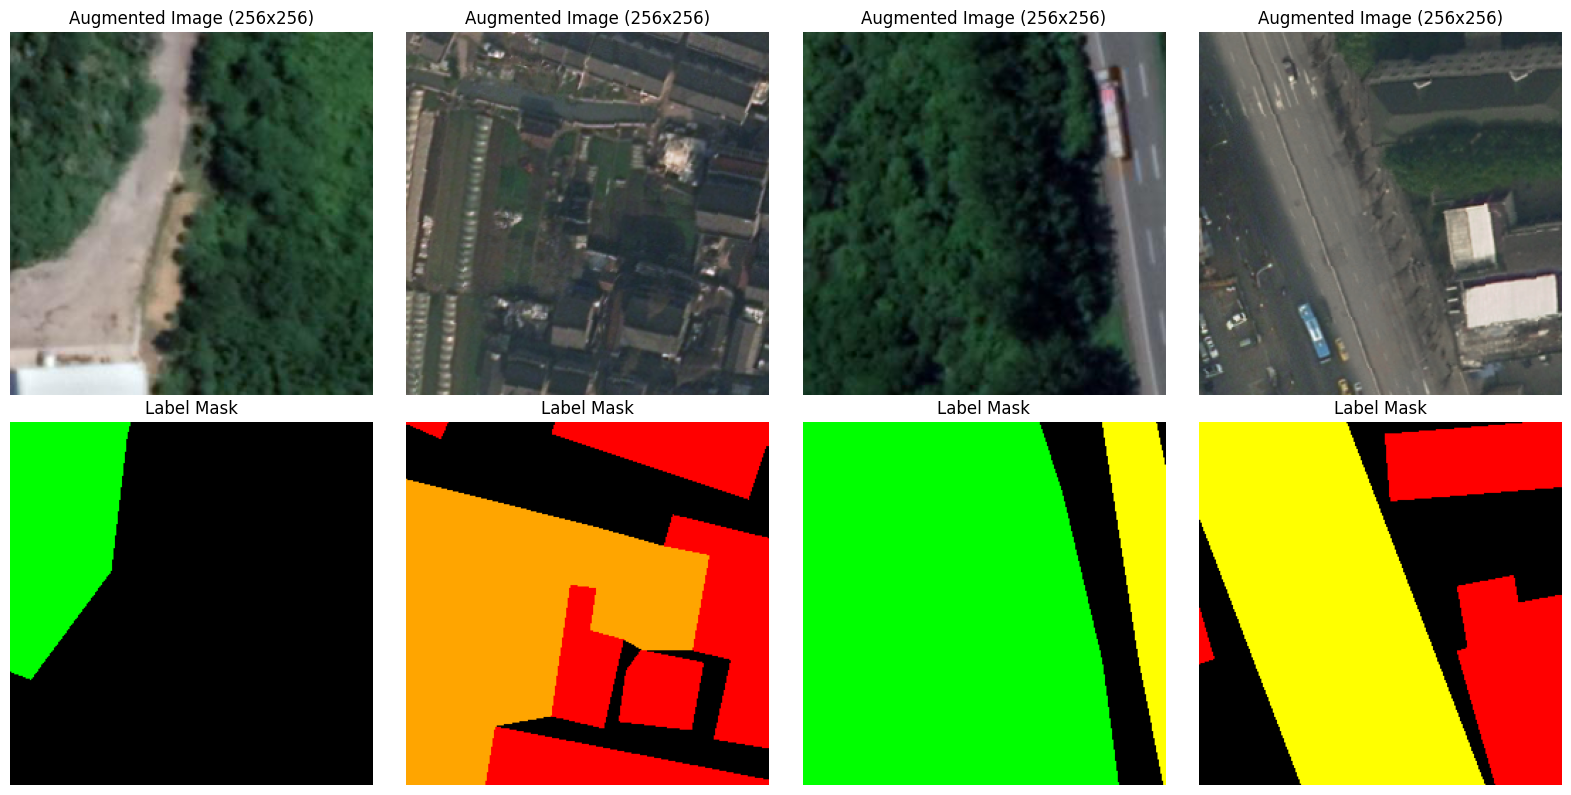

In [ ]:
#phase 1

import os
import glob
import cv2
import numpy as np
import torch
import kagglehub
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2


dataset_path = path
print(f"Dataset downloaded to: {dataset_path}")


#PYTORCH DATASET CLASS
class LoveDADataset(Dataset):
    def __init__(self, root_dir, split='Train', transform=None):
        """
        Args:
            root_dir (str): Path to the extracted dataset.
            split (str): 'Train' or 'Val'.
            transform (albumentations.Compose): Data augmentation pipeline.
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        search_pattern = os.path.join(root_dir, split, '**', 'images_png', '*.png')
        self.image_paths = sorted(glob.glob(search_pattern, recursive=True))

        # Match mask paths based on image paths
        self.mask_paths = [p.replace('images_png', 'masks_png') for p in self.image_paths]

        print(f"Found {len(self.image_paths)} images for {self.split} split.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Read Image and convert BGR to RGB
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read Mask (Grayscale)
        mask_path = self.mask_paths[idx]
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        mask = np.where(mask == 0, 255, mask - 1)

        #Apply Albumentations (handles both image and mask simultaneously)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.to(torch.long)

        return image, mask

train_transform = A.Compose([
    A.RandomCrop(width=256, height=256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), #Standard ImageNet normalization
    ToTensorV2(),
])

val_transform = A.Compose([
    A.CenterCrop(width=256, height=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


#create Dataset instances
train_dataset = LoveDADataset(root_dir=dataset_path, split='Train', transform=train_transform)
val_dataset = LoveDADataset(root_dir=dataset_path, split='Val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)


def visualize_batch(dataloader):
    """Pulls one batch from the dataloader and plots the first 4 images/masks"""
    images, masks = next(iter(dataloader))

    # Denormalize images for viewing
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    # Color map for the 7 classes (for display purposes)
    colors = [
        [0, 0, 0],       # 0: Background (Black)
        [255, 0, 0],     # 1: Building (Red)
        [255, 255, 0],   # 2: Road (Yellow)
        [0, 0, 255],     # 3: Water (Blue)
        [150, 150, 150], # 4: Barren (Gray)
        [0, 255, 0],     # 5: Forest (Green)
        [255, 165, 0]    # 6: Agriculture (Orange)
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i in range(4):
        img_np = images[i].permute(1, 2, 0).numpy()
        mask_np = masks[i].numpy()

        # Map class indices back to RGB colors for the mask
        colored_mask = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_idx, color in enumerate(colors):
            colored_mask[mask_np == class_idx] = color

        axes[0, i].imshow(img_np)
        axes[0, i].set_title("Augmented Image (256x256)")
        axes[0, i].axis("off")

        axes[1, i].imshow(colored_mask)
        axes[1, i].set_title("Label Mask")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

print("Visualizing a training batch...")
visualize_batch(train_loader)

In [ ]:
#phase 2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

#ASPP
class ASPPConv(nn.Sequential):
    """Standard ASPP Convolution with varying dilation rates"""
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

class ASPPPooling(nn.Sequential):
    """Global Average Pooling branch of the ASPP"""
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        size = x.shape[-2:]
        # Pool, pass through 1x1 conv, then upsample back to original ASPP size
        for mod in self:
            x = mod(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)

class ASPP(nn.Module):
    """The Complete ASPP Module"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Branch 1 1x1 Convolution
        self.mod1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        # Branches 2, 3, 4: 3x3 Atrous Convolutions (rates 6, 12, 18 as per paper)
        self.mod2 = ASPPConv(in_channels, out_channels, dilation=6)
        self.mod3 = ASPPConv(in_channels, out_channels, dilation=12)
        self.mod4 = ASPPConv(in_channels, out_channels, dilation=18)

        self.mod5 = ASPPPooling(in_channels, out_channels)

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5) #Dropout prevents overfitting
        )

    def forward(self, x):
        res = [self.mod1(x), self.mod2(x), self.mod3(x), self.mod4(x), self.mod5(x)]
        return self.project(torch.cat(res, dim=1))


#og deeplabv3+ model
class BaselineDeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        #Load Pretrained MobileNetV2
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features

        self.low_level_features = mobilenet[:4]
        self.high_level_features = mobilenet[4:]

        self.aspp = ASPP(in_channels=1280, out_channels=256)

        self.reduce_low_level = nn.Sequential(
            nn.Conv2d(24, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        #decoder Module
        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # Final output layer projects to the number of classes (7 for LoveDA)
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        input_shape = x.shape[-2:] # Save original shape (256x256)
        #encoder
        low_level = self.low_level_features(x)
        high_level = self.high_level_features(low_level)

        aspp_out = self.aspp(high_level)

        aspp_out = F.interpolate(aspp_out, size=low_level.shape[-2:], mode='bilinear', align_corners=False)

        #decoder
        low_level_reduced = self.reduce_low_level(low_level)
        decoder_in = torch.cat([low_level_reduced, aspp_out], dim=1)

        out = self.decoder(decoder_in)
        out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=False)

        return out

if __name__ == "__main__":
    print("Initializing Baseline Deeplabv3+...")
    model = BaselineDeepLabV3Plus(num_classes=7)

    dummy_input = torch.randn(4, 3, 256, 256)

    print("Feeding dummy images through the network...")
    output = model(dummy_input)

    print(f"Output shape: {output.shape}")
    if output.shape == (4, 7, 256, 256):
        print("Success! The network architecture is intact and tensor shapes align.")

Initializing Baseline Deeplabv3+...
Feeding dummy images through the network...
Output shape: torch.Size([4, 7, 256, 256])
Success! The network architecture is intact and tensor shapes align.


In [ ]:
#phase 3 -6 (implementing the 4 diff tings that the paper did to improve the model)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import math

#COORDINATE ATTENTION (CA) MODULE
class CoordinateAttention(nn.Module):
    def __init__(self, in_channels, reduction=32):
        super().__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = max(8, in_channels // reduction)
        self.conv1 = nn.Conv2d(in_channels, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.relu = nn.ReLU(inplace=True)

        self.conv_h = nn.Conv2d(mip, in_channels, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, in_channels, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        n, c, h, w = x.size()
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.relu(self.bn1(self.conv1(y)))

        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        a_h = self.sigmoid(self.conv_h(x_h))
        a_w = self.sigmoid(self.conv_w(x_w))

        return x * a_h * a_w

#FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

#IMPROVED ASPP MODULE (2D DECOMPOSITION)
class ImprovedASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__(
            # Replaced single 3x3 with 3x1 and 1x3 to reduce parameters by 33%
            nn.Conv2d(in_channels, out_channels, (3, 1), padding=(dilation, 0), dilation=(dilation, 1), bias=False),
            nn.Conv2d(out_channels, out_channels, (1, 3), padding=(0, dilation), dilation=(1, dilation), bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

class ASPPPooling(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        size = x.shape[-2:]
        for mod in self:
            x = mod(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)

class ImprovedASPP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.mod1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.mod2 = ImprovedASPPConv(in_channels, out_channels, dilation=6)
        self.mod3 = ImprovedASPPConv(in_channels, out_channels, dilation=12)
        self.mod4 = ImprovedASPPConv(in_channels, out_channels, dilation=18)
        self.mod5 = ASPPPooling(in_channels, out_channels)

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        res = [self.mod1(x), self.mod2(x), self.mod3(x), self.mod4(x), self.mod5(x)]
        return self.project(torch.cat(res, dim=1))

#FEATURE POST-PROCESSING MODULE (FPPM)
class NonLocalBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.inter_channels = in_channels // 2
        self.g = nn.Conv2d(in_channels, self.inter_channels, 1)
        self.theta = nn.Conv2d(in_channels, self.inter_channels, 1)
        self.phi = nn.Conv2d(in_channels, self.inter_channels, 1)
        self.W = nn.Conv2d(self.inter_channels, in_channels, 1)

    def forward(self, x):
        b, c, h, w = x.size()
        g_x = self.g(x).view(b, self.inter_channels, -1).permute(0, 2, 1)
        theta_x = self.theta(x).view(b, self.inter_channels, -1).permute(0, 2, 1)
        phi_x = self.phi(x).view(b, self.inter_channels, -1)

        f = torch.matmul(theta_x, phi_x)
        f_div_C = F.softmax(f, dim=-1)

        y = torch.matmul(f_div_C, g_x).permute(0, 2, 1).contiguous()
        y = y.view(b, self.inter_channels, h, w)
        W_y = self.W(y)
        return W_y + x

class ECA(nn.Module):
    def __init__(self, channels):
        super().__init__()
        gamma, b = 2, 1
        t = int(abs((math.log2(channels) / gamma) + b / gamma))
        k = t if t % 2 else t + 1

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=(k - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2)).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

class FPPM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.nl_full = NonLocalBlock(in_channels)
        self.nl_half = NonLocalBlock(in_channels)
        self.nl_quarter = NonLocalBlock(in_channels)

        self.eca = ECA(in_channels * 3)
        self.reduce = nn.Conv2d(in_channels * 3, in_channels, 1, bias=False)

    def apply_nl_to_blocks(self, x, num_blocks, nl_module):
        b, c, h, w = x.size()
        bh, bw = h // num_blocks, w // num_blocks

        x_reshaped = x.view(b, c, num_blocks, bh, num_blocks, bw)
        x_reshaped = x_reshaped.permute(0, 2, 4, 1, 3, 5).contiguous().view(-1, c, bh, bw)

        out = nl_module(x_reshaped)

        out = out.view(b, num_blocks, num_blocks, c, bh, bw)
        out = out.permute(0, 3, 1, 4, 2, 5).contiguous().view(b, c, h, w)
        return out

    def forward(self, x):
        b1 = self.nl_full(x)
        b2 = self.apply_nl_to_blocks(x, 2, self.nl_half)
        b3 = self.apply_nl_to_blocks(x, 4, self.nl_quarter)

        out = torch.cat([b1, b2, b3], dim=1)
        out = self.eca(out)
        out = self.reduce(out)
        return out

# MASTER ASSEMBLY: FULLY IMPROVED DEEPLABV3+
class ImprovedDeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features
        self.low_level_features = mobilenet[:4]
        self.high_level_features = mobilenet[4:]

        #Added CA Module right after the backbone
        self.ca_module = CoordinateAttention(in_channels=1280)

        #Replaced standard ASPP with Improved ASPP
        self.aspp = ImprovedASPP(in_channels=1280, out_channels=256)

        self.reduce_low_level = nn.Sequential(
            nn.Conv2d(24, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.decoder_convs = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        #Added FPPM Module right after decoder convolutions
        self.fppm = FPPM(in_channels=256)

        self.classifier = nn.Conv2d(256, num_classes, 1)

    def forward(self, x):
        input_shape = x.shape[-2:]

        low_level = self.low_level_features(x)
        high_level = self.high_level_features(low_level)

        # Apply CA Attention
        high_level = self.ca_module(high_level)

        aspp_out = self.aspp(high_level)
        aspp_out = F.interpolate(aspp_out, size=low_level.shape[-2:], mode='bilinear', align_corners=False)

        low_level_reduced = self.reduce_low_level(low_level)
        decoder_in = torch.cat([low_level_reduced, aspp_out], dim=1)

        out = self.decoder_convs(decoder_in)

        # Apply FPPM Feature Post-Processing
        out = self.fppm(out)

        out = self.classifier(out)
        out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=False)

        return out

#QUICK TEST & VERIFICATION to check if working
if __name__ == "__main__":
    print("Initializing Fully Improved Deeplabv3+...")
    model = ImprovedDeepLabV3Plus(num_classes=7)

    #dummy image batch with 4 images to check if working
    dummy_input = torch.randn(4, 3, 256, 256)
    dummy_targets = torch.randint(0, 7, (4, 256, 256))

    print("Running forward pass through CA, Improved ASPP, and FPPM...")
    output = model(dummy_input)

    print("Calculating Focal Loss...")
    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    loss = criterion(output, dummy_targets)

    print(f"Output shape: {output.shape}")
    print(f"Initial Focal Loss: {loss.item():.4f}")
    if output.shape == (4, 7, 256, 256):
        print("Success! All research paper modules integrated perfectly.")

Initializing Fully Improved Deeplabv3+...
Running forward pass through CA, Improved ASPP, and FPPM...
Calculating Focal Loss...
Output shape: torch.Size([4, 7, 256, 256])
Initial Focal Loss: 0.3596
Success! All research paper modules integrated perfectly.


In [ ]:
#training - phase 7
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os


#EVALUATION METRICS & LOSS FUNCTION
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, ignore_index=255):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index

    def forward(self, inputs, targets):
        # Calculate cross entropy, explicitly ignoring the 255 index
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', ignore_index=self.ignore_index)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        valid_mask = (targets != self.ignore_index).float()
        focal_loss = focal_loss * valid_mask

        # Avoid division by zero
        return focal_loss.sum() / max(valid_mask.sum(), 1.0)


class MetricsHelper:
    """Calculates DICE, mIoU, and Global Accuracy exactly as described in the paper"""
    def __init__(self, num_classes=7, ignore_index=255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def compute_iou(self, preds, targets):
        #Convert logits [B, C, H, W] to class predictions [B, H, W]
        preds = torch.argmax(preds, dim=1)

        ious = []
        for cls in range(self.num_classes):
            pred_inds = preds == cls
            target_inds = targets == cls

            intersection = (pred_inds[target_inds]).long().sum().item()
            union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection

            if union == 0:
                ious.append(float('nan'))  # Ignore class if it doesn't exist in this specific patch
            else:
                ious.append(float(intersection) / float(max(union, 1)))
        return ious

    def compute_global_accuracy(self, preds, targets):
        preds = torch.argmax(preds, dim=1)

        #Only calculate accuracy on valid pixels
        valid_mask = targets != self.ignore_index
        correct = ((preds == targets) & valid_mask).float().sum().item()
        total = valid_mask.float().sum().item()

        return correct / max(total, 1.0)

def train_model(model, train_loader, val_loader, criterion, num_epochs=50, is_dry_run=True):
    print(f"--- Starting Training ({'DRY RUN' if is_dry_run else 'FULL RUN'}) ---")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on device: {device}")

    model = model.to(device)
    criterion = criterion.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    metrics = MetricsHelper(num_classes=7, ignore_index=255)

    best_miou = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        #training phase
        model.train()
        train_loss = 0.0

        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            # Forward Pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward Pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            # Dry Run: to test only for 2 loops
            if is_dry_run and batch_idx == 1:
                print("Dry run active: Stopping training epoch early.")
                break

        epoch_train_loss = train_loss / (2 if is_dry_run else len(train_loader.dataset))
        print(f"Training Loss: {epoch_train_loss:.4f}")

        #VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        total_iou = np.zeros(7)
        valid_classes = np.zeros(7)
        total_acc = 0.0

        with torch.no_grad():
            for batch_idx, (images, masks) in enumerate(val_loader):
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

                #Calculate Validation Metrics
                batch_ious = metrics.compute_iou(outputs, masks)
                for i, iou in enumerate(batch_ious):
                    if not np.isnan(iou):
                        total_iou[i] += iou
                        valid_classes[i] += 1

                total_acc += metrics.compute_global_accuracy(outputs, masks)

                if is_dry_run and batch_idx == 1:
                    print("Dry run active: Stopping validation epoch early.")
                    break

        # Tally final epoch metrics
        epoch_val_loss = val_loss / (2 if is_dry_run else len(val_loader.dataset))
        mean_ious = total_iou / np.maximum(valid_classes, 1)
        miou = np.nanmean(mean_ious)
        global_acc = total_acc / (2 if is_dry_run else len(val_loader))

        print(f"Validation Loss: {epoch_val_loss:.4f}")
        print(f"Validation mIoU: {miou:.4f} | Global Accuracy: {global_acc:.4f}")

        if miou > best_miou:
            best_miou = miou
            checkpoint_path = '/content/drive/MyDrive/best_deeplabv3plus_model.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f"-> Model saved to {checkpoint_path} (mIoU improved to {best_miou:.4f})")

    print("\nTraining Complete!")
    return model


if __name__ == "__main__":
    # Initialize the newly updated FocalLoss
    criterion = FocalLoss(alpha=0.25, gamma=2.0, ignore_index=255)

    train_model(model, train_loader, val_loader, criterion, num_epochs=40, is_dry_run=False)

--- Starting Training (FULL RUN) ---
Training on device: cuda

Epoch 1/40
--------------------
Training Loss: 0.1768
Validation Loss: 0.1640
Validation mIoU: 0.2863 | Global Accuracy: 0.5467
-> Model saved to /content/drive/MyDrive/best_deeplabv3plus_model.pth (mIoU improved to 0.2863)

Epoch 2/40
--------------------
Training Loss: 0.1382
Validation Loss: 0.1445
Validation mIoU: 0.3204 | Global Accuracy: 0.5705
-> Model saved to /content/drive/MyDrive/best_deeplabv3plus_model.pth (mIoU improved to 0.3204)

Epoch 3/40
--------------------
Training Loss: 0.1254
Validation Loss: 0.1703
Validation mIoU: 0.3046 | Global Accuracy: 0.5525

Epoch 4/40
--------------------
Training Loss: 0.1177
Validation Loss: 0.1759
Validation mIoU: 0.2934 | Global Accuracy: 0.5508

Epoch 5/40
--------------------
Training Loss: 0.1110
Validation Loss: 0.1578
Validation mIoU: 0.2974 | Global Accuracy: 0.5486

Epoch 6/40
--------------------
Training Loss: 0.1092
Validation Loss: 0.1630
Validation mIoU: 0.320

Updated weights after training are: /content/drive/MyDrive/best_deeplabv3plus_model.pth
Loading weights from /content/drive/MyDrive/best_deeplabv3plus_model.pth...
Model loaded successfully. Generating visualizations...
Running inference...


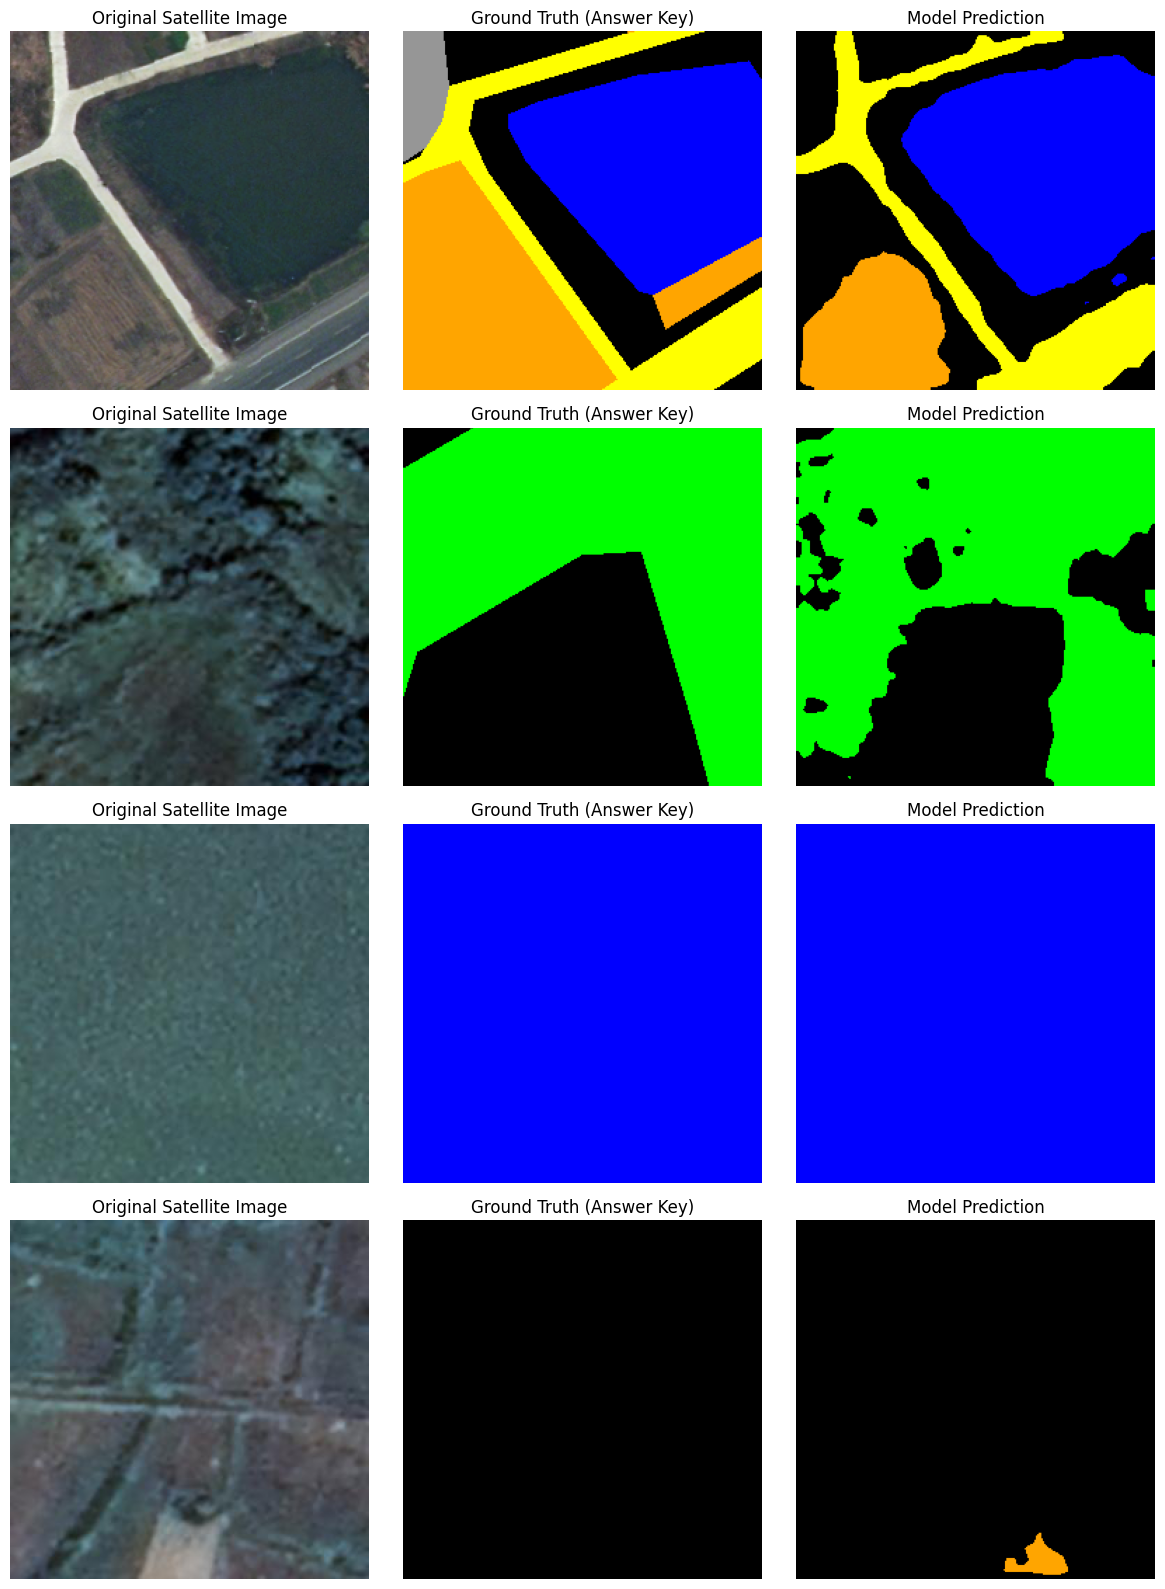

In [ ]:
#phase 8 - testing and visualising
import torch
import numpy as np
import matplotlib.pyplot as plt

def load_trained_model(model_class, weights_path, device):
    """Loads the saved weights into the model architecture"""
    print(f"Loading weights from {weights_path}...")

    # Initialize the architecture (Must be the exact same class used in training)
    model = model_class(num_classes=7)

    # Load the weights into the model
    # map_location ensures it works even if you are currently on a CPU
    model.load_state_dict(torch.load(weights_path, map_location=device))

    model = model.to(device)
    model.eval() # Set to evaluation mode (turns off dropout, etc.)
    return model

def visualize_predictions(model, dataloader, device, num_images=4):
    """Runs inference on a batch and plots Image vs Ground Truth vs Prediction"""

    # Grab one batch of validation data
    images, masks = next(iter(dataloader))
    images_gpu = images.to(device)

    print("Running inference...")
    with torch.no_grad():
        outputs = model(images_gpu)
        # Convert logits to final class predictions (argmax across channel dimension)
        predictions = torch.argmax(outputs, dim=1).cpu()

    images = images.cpu()
    masks = masks.cpu()


    colors = [
        [0, 0, 0],       # 0: Background (Black)
        [255, 0, 0],     # 1: Building (Red)
        [255, 255, 0],   # 2: Road (Yellow)
        [0, 0, 255],     # 3: Water (Blue)
        [150, 150, 150], # 4: Barren (Gray)
        [0, 255, 0],     # 5: Forest (Green)
        [255, 165, 0]    # 6: Agriculture (Orange)
    ]

    def map_to_color(tensor_mask):
        """Converts a 2D class index tensor into a 3D RGB image"""
        mask_np = tensor_mask.numpy()
        colored_mask = np.zeros((256, 256, 3), dtype=np.uint8)

        for class_idx, color in enumerate(colors):
            colored_mask[mask_np == class_idx] = color

        colored_mask[mask_np == 255] = [255, 255, 255] # Make unknown pixels white

        return colored_mask

    # Denormalize images for viewing
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

    for i in range(num_images):
        #Original Image
        img_denorm = images[i] * std + mean
        img_denorm = torch.clamp(img_denorm, 0, 1)
        axes[i, 0].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Original Satellite Image")
        axes[i, 0].axis("off")

        #Ground Truth Mask
        gt_colored = map_to_color(masks[i])
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title("Ground Truth (Answer Key)")
        axes[i, 1].axis("off")

        #Model Prediction
        pred_colored = map_to_color(predictions[i])
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title(f"Model Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Path to the smartest version of model (from Epoch 28)
    weights_path = '/content/drive/MyDrive/best_deeplabv3plus_model.pth'
    print(f"Updated weights after training are: {weights_path}")
    # IMPORTANT: We use the ImprovedDeepLabV3Plus class defined in Phase 3-6
    try:
        # Load the model
        trained_model = load_trained_model(ImprovedDeepLabV3Plus, weights_path, device)

        # Run the visualization on the Validation dataset (data the model hasn't memorized)
        print("Model loaded successfully. Generating visualizations...")
        visualize_predictions(trained_model, val_loader, device, num_images=4)

    except FileNotFoundError:
        print(f"Error: Could not find the weights file at {weights_path}.")
        print("Ensure your Google Drive is mounted and the path is correct.")

Loading weights from /content/drive/MyDrive/best_deeplabv3plus_model.pth...

Running visual inference...


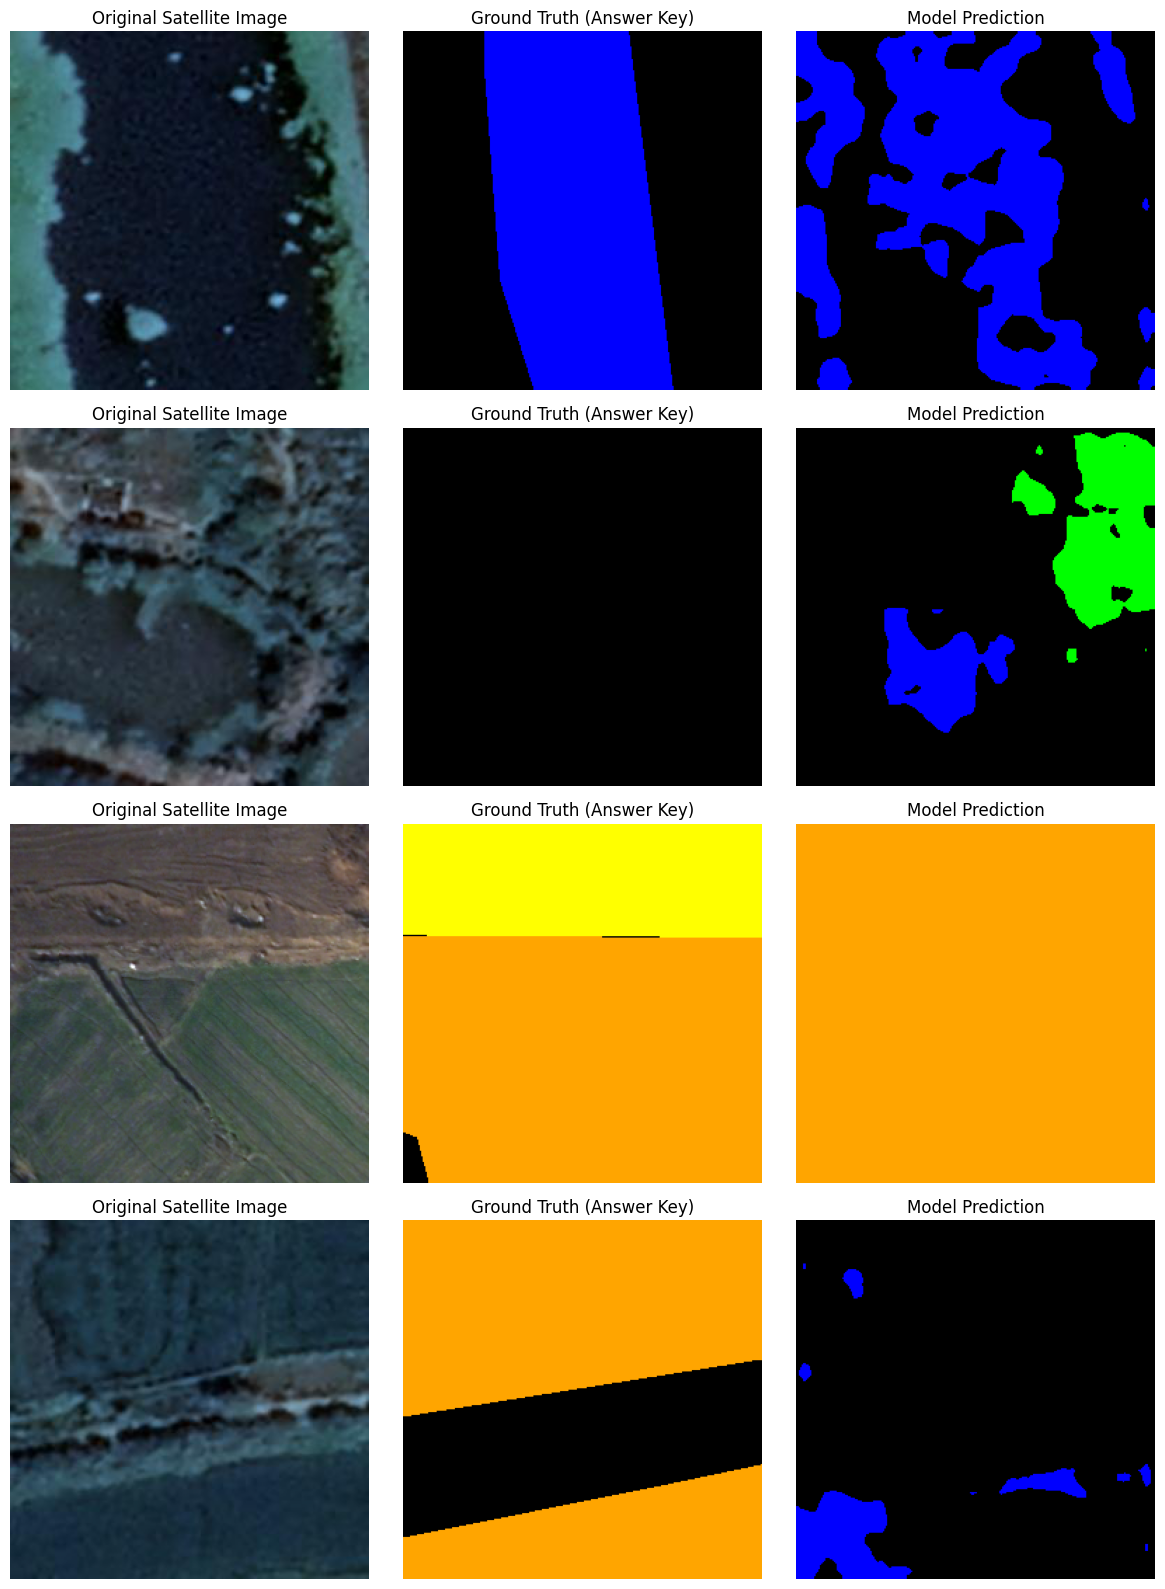


Evaluating full validation dataset...

FINAL QUANTITATIVE RESULTS (Paper Style)
Background      IoU:  45.90%
Building        IoU:  42.79%
Road            IoU:  29.90%
Water           IoU:  54.99%
Barren          IoU:  15.63%
Forest          IoU:  25.66%
Agriculture     IoU:  44.87%
----------------------------------------
Mean IoU (mIoU)    :  37.11%
Global Accuracy    :  64.65%


In [ ]:
#analsyis of results

import torch
import numpy as np
import matplotlib.pyplot as plt
import random


def load_trained_model(model_class, weights_path, device):
    """Loads the saved weights into the model architecture"""
    print(f"Loading weights from {weights_path}...")

    model = model_class(num_classes=7)
    model.load_state_dict(torch.load(weights_path, map_location=device))

    model = model.to(device)
    model.eval() # Set to evaluation mode (turns off dropout, etc.)
    return model

def visualize_predictions(model, dataloader, device, num_images=4):
    """Runs inference on a random batch and plots Image vs Ground Truth vs Prediction"""

    # Skip a random number of batches to get different images every time
    data_iter = iter(dataloader)
    skip_batches = random.randint(0, len(dataloader) - 1)
    for _ in range(skip_batches):
        next(data_iter)

    # Grab the random batch of validation data
    images, masks = next(data_iter)

    images_gpu = images.to(device)

    print("\nRunning visual inference...")
    with torch.no_grad():
        outputs = model(images_gpu)
        # Convert logits to final class predictions (argmax across channel dimension)
        predictions = torch.argmax(outputs, dim=1).cpu()

    images = images.cpu()
    masks = masks.cpu()

    colors = [
        [0, 0, 0],       # 0: Background (Black)
        [255, 0, 0],     # 1: Building (Red)
        [255, 255, 0],   # 2: Road (Yellow)
        [0, 0, 255],     # 3: Water (Blue)
        [150, 150, 150], # 4: Barren (Gray)
        [0, 255, 0],     # 5: Forest (Green)
        [255, 165, 0]    # 6: Agriculture (Orange)
    ]

    def map_to_color(tensor_mask):
        """Converts a 2D class index tensor into a 3D RGB image"""
        mask_np = tensor_mask.numpy()
        colored_mask = np.zeros((256, 256, 3), dtype=np.uint8)

        for class_idx, color in enumerate(colors):
            colored_mask[mask_np == class_idx] = color

        # Handle the ignore_index (255) if it exists in the ground truth
        colored_mask[mask_np == 255] = [255, 255, 255] # Make unknown pixels white

        return colored_mask

    # Denormalize images for viewing
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

    for i in range(num_images):
        # 1. Original Image
        img_denorm = images[i] * std + mean
        img_denorm = torch.clamp(img_denorm, 0, 1)
        axes[i, 0].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Original Satellite Image")
        axes[i, 0].axis("off")

        gt_colored = map_to_color(masks[i])
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title("Ground Truth (Answer Key)")
        axes[i, 1].axis("off")
        pred_colored = map_to_color(predictions[i])
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title(f"Model Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

#FULL DATASET QUANTITATIVE EVALUATION
def evaluate_full_dataset(model, dataloader, device, num_classes=7, ignore_index=255):
    """Calculates final paper metrics across the entire validation dataset"""
    print("\nEvaluating full validation dataset...")

    total_iou = np.zeros(num_classes)
    valid_classes = np.zeros(num_classes)
    total_correct = 0
    total_pixels = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Per-class IoU Calculation
            for cls in range(num_classes):
                pred_inds = preds == cls
                target_inds = masks == cls

                intersection = (pred_inds[target_inds]).long().sum().item()
                union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection

                if union > 0:
                    total_iou[cls] += float(intersection) / float(max(union, 1))
                    valid_classes[cls] += 1

            # Global Accuracy Calculation
            valid_mask = masks != ignore_index
            total_correct += ((preds == masks) & valid_mask).float().sum().item()
            total_pixels += valid_mask.float().sum().item()

    # Averages
    mean_ious = total_iou / np.maximum(valid_classes, 1)
    miou = np.nanmean(mean_ious)
    global_acc = total_correct / max(total_pixels, 1.0)

    class_names = ["Background", "Building", "Road", "Water", "Barren", "Forest", "Agriculture"]

    print("\n" + "="*40)
    print("FINAL QUANTITATIVE RESULTS (Paper Style)")
    print("="*40)
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<15} IoU: {mean_ious[i]*100:>6.2f}%")
    print("-" * 40)
    print(f"{'Mean IoU (mIoU)':<15}    : {miou*100:>6.2f}%")
    print(f"{'Global Accuracy':<15}    : {global_acc*100:>6.2f}%")
    print("="*40)


if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Path to the smartest version of your model (from Epoch 28)
    weights_path = '/content/drive/MyDrive/best_deeplabv3plus_model.pth'

    try:
        # Load the model using the Improved Architecture
        trained_model = load_trained_model(ImprovedDeepLabV3Plus, weights_path, device)
        visualize_predictions(trained_model, val_loader, device, num_images=4)

        #eval
        evaluate_full_dataset(trained_model, val_loader, device)

    except FileNotFoundError:
        print(f"Error: Could not find the weights file at {weights_path}.")
        print("Ensure your Google Drive is mounted and the path is correct.")